In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_pre=pd.read_csv('../../../data/processed/wearables_by_period/df_15_primeros_EB2_prog.csv')#, index_col=0)

In [3]:
df_post=pd.read_csv('../../../data/processed/wearables_by_period/df_15_previos_HDM_prog.csv')#, index_col=0)

In [4]:
df_pre.loc[df_pre.heart_rate_hr_mean<0,'heart_rate_hr_mean']=np.nan
df_pre.loc[df_pre.heart_rate_hr_baseline<0,'heart_rate_hr_baseline']=np.nan
df_pre.loc[df_pre.heart_rate_hr_min<0,'heart_rate_hr_min']=np.nan
df_pre.loc[df_pre.heart_rate_hr_max<0,'heart_rate_hr_max']=np.nan

df_post.loc[df_post.heart_rate_hr_mean<0,'heart_rate_hr_mean']=np.nan
df_post.loc[df_post.heart_rate_hr_baseline<0,'heart_rate_hr_baseline']=np.nan
df_post.loc[df_post.heart_rate_hr_min<0,'heart_rate_hr_min']=np.nan
df_post.loc[df_post.heart_rate_hr_max<0,'heart_rate_hr_max']=np.nan

In [5]:
df_pre.loc[df_pre.sleep_duration>(60*60*24),'sleep_duration']=np.nan
df_post.loc[df_post.sleep_duration>(60*60*24),'sleep_duration']=np.nan

In [6]:
df_pre['Period']=1
df_post['Period']=2

In [7]:
merge=pd.concat([df_pre, df_post])

In [8]:
# Convert date_time to datetime if it's not already
df_pre['date_time'] = pd.to_datetime(df_pre['date_time'])

# For each user, find their earliest date and calculate days since then
df_pre['day'] = df_pre.groupby('ID')['date_time'].transform(
    lambda x: (x - x.min()).dt.days + 1
)

In [9]:
# Convert date_time to datetime if it's not already
df_post['date_time'] = pd.to_datetime(df_post['date_time'])

# For each user, find their earliest date and calculate days since then
df_post['day'] = df_post.groupby(['ID','match_set_id'])['date_time'].transform(
    lambda x: (x - x.min()).dt.days + 1
)

In [10]:
merge=pd.concat([df_pre,df_post])

In [11]:
# Create a custom sorting key
def sort_key(day):
    if day > 0:
        return day  # Positive days: 1, 2, 3...15
    else:
        return 15 + (day + 16)  # Negative days: -15→0 maps to 16→31

# Sort your data using this key
merge['sort_order'] = merge['day'].apply(sort_key)
merge = merge.sort_values('sort_order')



In [12]:
merge.loc[merge.Respuesta=='no-E.PD','Respuesta']='non-E.PD controls'

merge['Respuesta'] = pd.Categorical(merge['Respuesta'],
                                   categories=['E.PD', 'non-E.PD controls'],
                                   ordered=True)

df_pre.loc[df_pre.Respuesta=='no-E.PD','Respuesta']='non-E.PD controls'

df_pre['Respuesta'] = pd.Categorical(df_pre['Respuesta'],
                                   categories=['E.PD', 'non-E.PD controls'],
                                   ordered=True)

df_post.loc[df_post.Respuesta=='no-E.PD','Respuesta']='non-E.PD controls'

df_post['Respuesta'] = pd.Categorical(df_post['Respuesta'],
                                   categories=['E.PD', 'non-E.PD controls'],
                                   ordered=True)


In [13]:
colors = sns.color_palette('Set2', n_colors=2)
colors=colors[-1::-1]

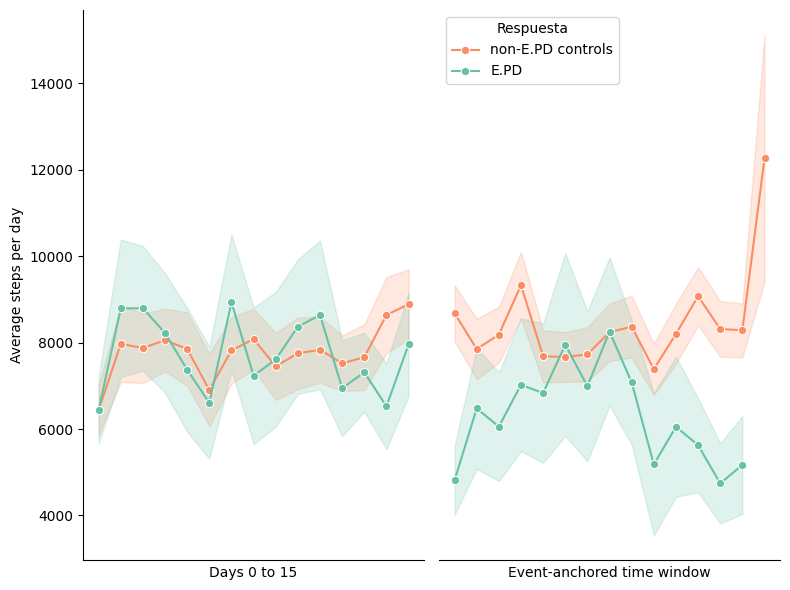

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

# LEFT PLOT - Pre data
sns.lineplot(data=df_pre, y='steps_steps_total', x='day', 
             hue='Respuesta', errorbar='se', ax=axes[0], marker='o', hue_order=['non-E.PD controls', 'E.PD'], palette=colors)
axes[0].set_xlabel('Days 0 to 15')
axes[0].set_ylabel('Average steps per day')
axes[0].set_xticks([])  # Remove x ticks
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# RIGHT PLOT - Post data
sns.lineplot(data=df_post, y='steps_steps_total', x='day', 
             hue='Respuesta', errorbar='se', ax=axes[1], marker='o', hue_order=['non-E.PD controls', 'E.PD'], palette=colors)
axes[1].set_xlabel('Event-anchored time window')
axes[1].set_ylabel('')
axes[1].set_xticks([])  # Remove x ticks
axes[1].tick_params(left=False, labelleft=False)  # Remove y ticks and labels on right onlyaxes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['left'].set_visible(False)

# Remove duplicate legend
axes[0].get_legend().remove()

# Place subplots close together
plt.subplots_adjust(wspace=0.05)

plt.tight_layout()
#plt.savefig('Periods_Steps.svg')

plt.show()



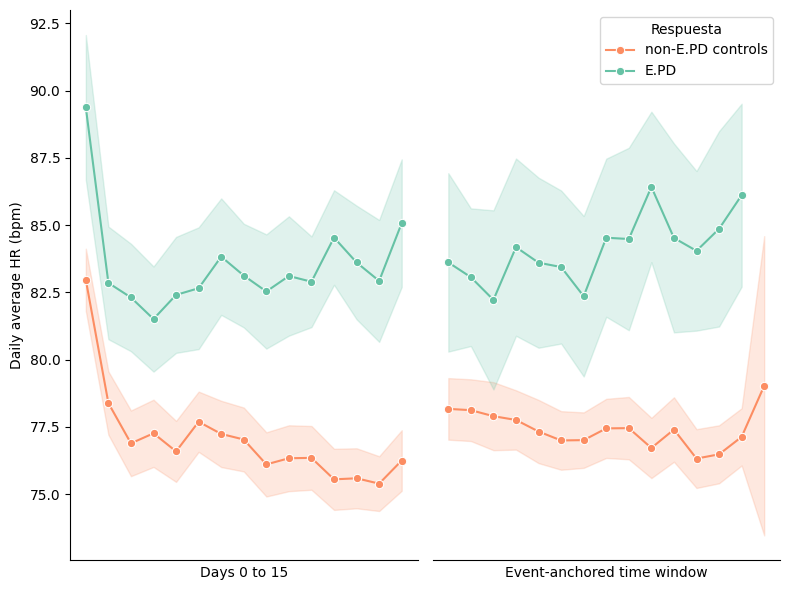

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

# LEFT PLOT - Pre data
sns.lineplot(data=df_pre, y='heart_rate_hr_mean', x='day', 
             hue='Respuesta', errorbar='se', ax=axes[0], marker='o', hue_order=['non-E.PD controls', 'E.PD'], palette=colors)
axes[0].set_xlabel('Days 0 to 15')
axes[0].set_ylabel('Daily average HR (bpm)')
axes[0].set_xticks([])  # Remove x ticks
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# RIGHT PLOT - Post data
sns.lineplot(data=df_post, y='heart_rate_hr_mean', x='day', 
             hue='Respuesta', errorbar='se', ax=axes[1], marker='o', hue_order=['non-E.PD controls', 'E.PD'], palette=colors)
axes[1].set_xlabel('Event-anchored time window')
axes[1].set_ylabel('')
axes[1].set_xticks([])  # Remove x ticks
axes[1].tick_params(left=False, labelleft=False)  # Remove y ticks and labels on right onlyaxes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['left'].set_visible(False)

# Remove duplicate legend
axes[0].get_legend().remove()

# Place subplots close together
plt.subplots_adjust(wspace=0.05)

plt.tight_layout()
#plt.savefig('Periods_HR.svg')

plt.show()

